Ciclo Crisis 52-55 ignorado (fuera de rango)
Ciclo Expansión 56-69 ignorado (fuera de rango)
Ciclo Recesión 70-81 ignorado (fuera de rango)
Ciclo Crisis 82-84 ignorado (fuera de rango)
Ciclo Expansión 56-69 ignorado (fuera de rango)
Ciclo Recesión 70-81 ignorado (fuera de rango)
Ciclo Crisis 82-84 ignorado (fuera de rango)


Datos cargados: 1988–2023
Columnas: ['oferta_total', 'produccion_bruta', 'importaciones', 'derechos_imp', 'impuestos_ind', 'margenes_transp']


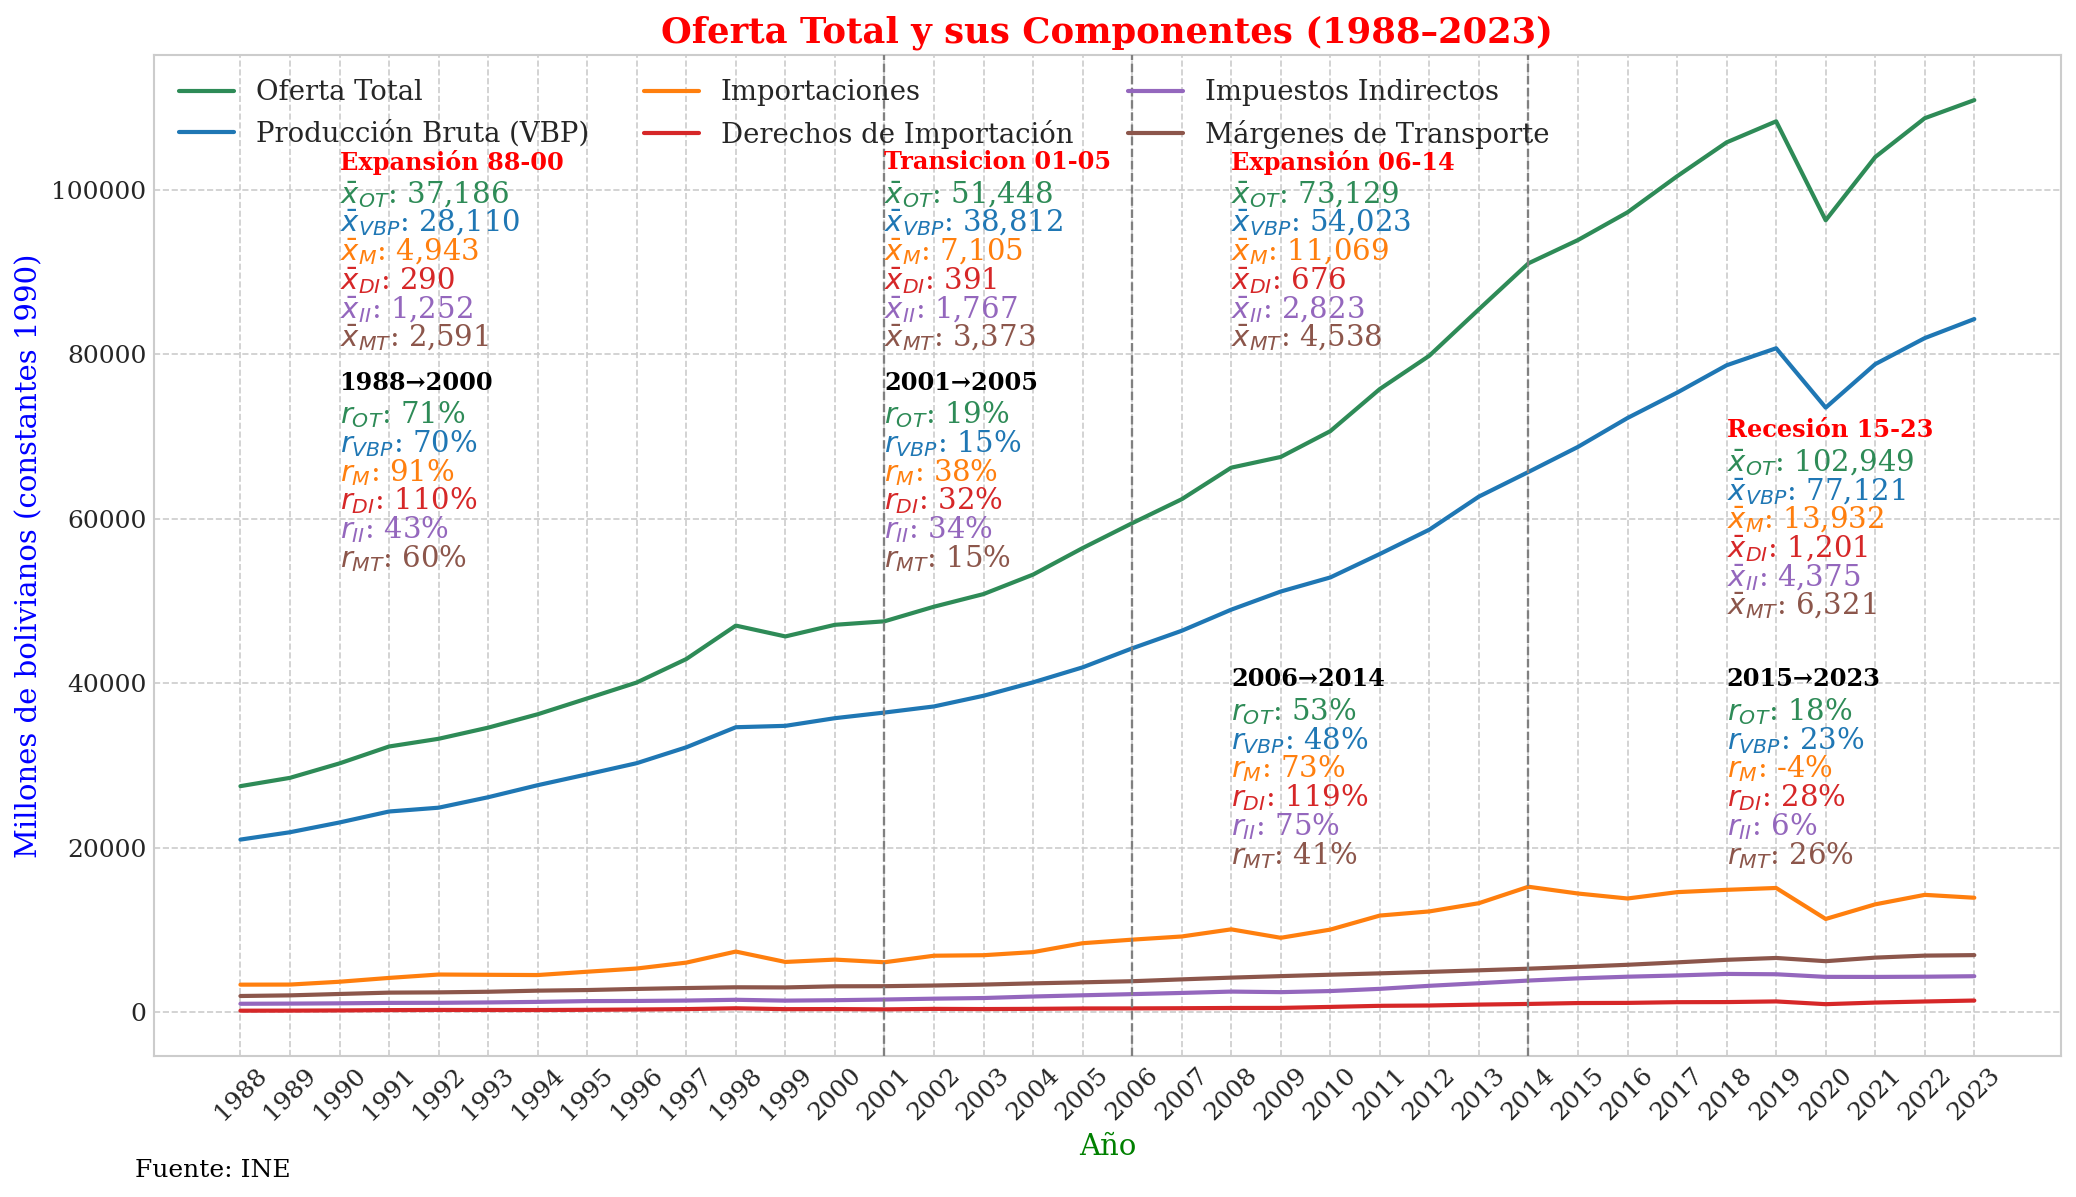

In [17]:
# ───────────────────────────── IMPORTS ──────────────────────────────
import os
import sys
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# IMPORTANTE: Importación correcta de las funciones auxiliares
from func_auxiliares.graficos_utils import (
    set_style,                          # Estilo corporativo
    init_base_plot,                     # Configuración base del gráfico
    add_hitos,                          # Líneas verticales de hitos
    add_cycle_means_multi,              # Medias por ciclo
    add_year_value_annotations,         # Anotaciones de valores por año
    add_period_growth_annotations_multi,# Tasas de crecimiento por período
    adjust_annot_years,                 # Ajustar años de anotación al DataFrame
    adjust_cycles,                      # Ajustar ciclos al DataFrame
    adjust_periods,                     # Ajustar períodos al DataFrame
)

from func_auxiliares.config import (
    DB_PATH,                            # Ruta a la base de datos
    CYCLES,                             # Diccionario de ciclos económicos
    ASSETS_DIR,                         # Directorio de assets
    annot_years,                        # Lista de años para anotaciones
    periodos_tasas,                     # Períodos para calcular tasas
    hitos_v,                            # Diccionario de hitos verticales
)

# ─────────────────────── 1. CONFIGURACIÓN GENERAL ───────────────────
output_dir = ASSETS_DIR / "serie_completa" / "oferta_total"
os.makedirs(output_dir, exist_ok=True)

set_style()  # Aplica el estilo corporativo unificado
# ───────────────────────── 2. CARGA DE DATOS ────────────────────────
with sqlite3.connect(str(DB_PATH)) as conn:
    df = (
        pd.read_sql(
            "SELECT * FROM oferta_total",
            conn,
            index_col="año"
        )
        .sort_index()
    )

# Convertir miles a millones para mejor legibilidad
valor_cols = ['oferta_total', 'produccion_bruta', 'importaciones', 
              'derechos_imp', 'impuestos_ind', 'margenes_transp']
df[valor_cols] = df[valor_cols] / 1000  # Miles a millones

print(f"Datos cargados: {df.index.min()}–{df.index.max()}")
print(f"Columnas: {list(df.columns)}")
df.head()
# ──────────────── 3. COMPONENTES Y PREPARACIÓN ──────────────────────
# Definir las series a graficar (tuplas de columna_df, etiqueta_display)
componentes = [
    ("oferta_total", "Oferta Total"),
    ("produccion_bruta", "Producción Bruta (VBP)"),
    ("importaciones", "Importaciones"),
    ("derechos_imp", "Derechos de Importación"),
    ("impuestos_ind", "Impuestos Indirectos"),
    ("margenes_transp", "Márgenes de Transporte"),
]

# Extraer solo los nombres de columnas
cols_componentes = [col for col, _ in componentes]

# Definir colores para cada serie
colors = {
    "oferta_total": "#2E8B57",              # Verde oscuro (serie principal)
    "produccion_bruta": "#1f77b4",          # Azul
    "importaciones": "#ff7f0e",             # Naranja
    "derechos_imp": "#d62728",              # Rojo
    "impuestos_ind": "#9467bd",             # Púrpura
    "margenes_transp": "#8c564b",           # Marrón
}

# Abreviaciones para anotaciones (texto más corto)
abbr_map = {
    "oferta_total": "OT",
    "produccion_bruta": "VBP",
    "importaciones": "M",
    "derechos_imp": "DI",
    "impuestos_ind": "II",
    "margenes_transp": "MT",
}
# ──────────────── 4. PREPARACIÓN DE CICLOS Y PERÍODOS ────────────────
# Ajustar configuraciones globales al DataFrame actual
annotate_years = adjust_annot_years(df, annot_years)
cycles = adjust_cycles(df, CYCLES)
periods = adjust_periods(df, periodos_tasas)

# Calcular estadísticas por ciclo (medias)
cycle_stats = {
    name: df.loc[period, cols_componentes].mean().to_dict()
    for name, period in cycles.items()
}
# ───────────── 5. OFFSETS Y UTILIDADES (POSICIONAMIENTO) ────────────

# A) Offsets para anotaciones de valores por año y serie
annotation_offsets = {
    # "oferta_total": {
    #     2001: (0, 1500),
    #     2006: (-1.5, 800),
    #     2014: (-3.2, -800),
    # },
    # "produccion_bruta": {
    #     2001: (0, 1200),
    #     2006: (1.2, 400),
    #     2014: (4, 0),
    # },
    # "importaciones": {
    #     2001: (0, 300),
    #     2006: (0, 500),
    #     2014: (0, 600),
    # },
    # "derechos_imp": {
    #     2001: (0, 50),
    #     2006: (0, 80),
    #     2014: (0, 100),
    # },
    # "impuestos_ind": {
    #     2001: (0, 150),
    #     2006: (0, 200),
    #     2014: (0, 250),
    # },
    # "margenes_transp": {
    #     2001: (0, 100),
    #     2006: (0, 150),
    #     2014: (0, 200),
    # },
}

# B) Offsets para líneas verticales de hitos
hitos_offset = {year: 0.8 for year in hitos_v}  # Altura relativa uniforme
 
# C) Offsets para medias por ciclo
medias_offsets = {
    "Expansión 88-00": (1990, 0.90),
    "Transicion 01-05": (2001, 0.90),
    "Expansión 06-14": (2008, 0.90),
    "Recesión 15-23": (2018, 0.62),
}

# D) Offsets para tasas de crecimiento por período
tasas_offsets = {
    "1988-2000": (1990, 0.67),
    "2001-2005": (2001, 0.67),
    "2006-2014": (2008, 0.36),
    "2015-2023": (2018, 0.36),
}
# ────────────────────────── 6. GRÁFICO BASE ──────────────────────────
fig, ax = init_base_plot(
    df=df,
    series=componentes,           # Lista de tuplas (columna, etiqueta)
    colors=colors,                # Diccionario de colores
    title=f"Oferta Total y sus Componentes ({df.index.min()}–{df.index.max()})",
    xlabel="Año",
    ylabel="Millones de bolivianos (constantes 1990)",
    source_text="Fuente: INE",
    figsize=(14, 8),             # Tamaño de figura
    legend_loc="upper left"       # Ubicación de leyenda
)
# ────────────────────── 7. ELEMENTOS GRÁFICOS ADICIONALES ────────────

# A) Líneas verticales de hitos históricos
add_hitos(ax, df.index, hitos_v, hitos_offset)

# B) Anotaciones de valores en años específicos
add_year_value_annotations(
    ax, df, annotate_years,
    cols_componentes, annotation_offsets, colors,
    arrow_lw=0.4,                # Grosor de flecha

)

# C) Medias por ciclo económico
y_max = ax.get_ylim()[1]
line_spacing = y_max * 0.03
add_cycle_means_multi(
    ax,
    cycle_stats,
    medias_offsets,
    abbr_map,
    colors,
    line_spacing=line_spacing             # Espaciado entre líneas
)

# D) Tasas de crecimiento por período
add_period_growth_annotations_multi(
    ax, df, periods,
    cols_componentes,
    tasas_offsets,
    colors,
    abbr_map,
          # Decimales en porcentajes
)
# ────────────────────────── 8. FINALIZACIÓN ──────────────────────────
plt.tight_layout()

# Guardar en formato PNG
filename_base = f"{output_dir}/oferta_total_componentes"
fig.savefig(f"{filename_base}.png", dpi=300, bbox_inches="tight")

plt.show()